In [3]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd


mercari_df= pd.read_csv('../data/mercari_train.tsv',sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [4]:
mercari_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB


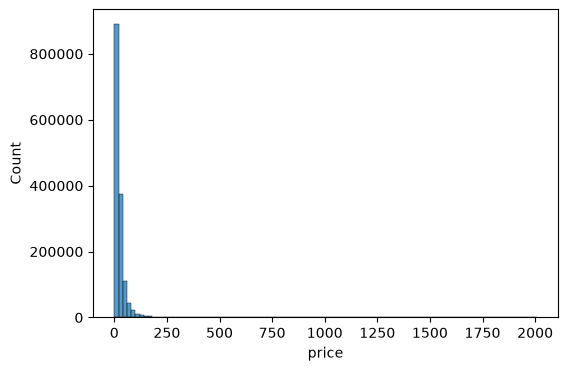

In [5]:
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns


y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

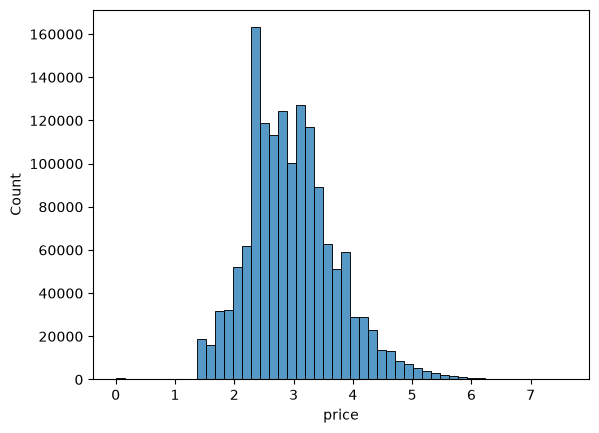

In [6]:
import numpy as np


y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [7]:
# price 값의 분포가 왼쪽에 몰려있으므로 price에 log처리

mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)


0    2.397895
1    3.970292
2    2.397895
Name: price, dtype: float64

In [8]:
print('Shipping 값 유형:\n',mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n',mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [9]:
# 카테고리: 대 / 중 / 소
# apply lambda에서 호출되는 대,중,소 분할 함수 생성, 대,중,소 값을 리스트 반환
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null' , 'Other_Null' , 'Other_Null']


# 위의 split_cat( )을 apply lambda에서 호출하여 대,중,소 컬럼을 mercari_df에 생성.
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
                        zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))


# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 갯수만 추출
print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 갯수 :', mercari_df['cat_jung'].nunique())
print('소분류 갯수 :', mercari_df['cat_so'].nunique())


대분류 유형 :
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 갯수 : 114
소분류 갯수 : 871


In [10]:
# brand_name 결측치(약 43%) 보완: 결측이 아닌 행에서 뽑은 브랜드 후보 목록을
# name 텍스트에서 찾아, 언급된 브랜드가 있으면 그걸로 역채움한다(fillna('Other_Null') 이전 단계).
# 새 브랜드 카테고리를 만드는 게 아니라 기존 brand_name 값 중에서만 채우므로 X_brand 차원 수는 그대로 유지됨.
known_brands = set(mercari_df.loc[mercari_df['brand_name'].notnull(), 'brand_name'].unique())

def find_brand_in_name(name, brand_set):
    words = str(name).split()
    n = len(words)
    for size in (3, 2, 1):  # 긴 조합부터 먼저 확인 (예: "Kate Spade"가 "Kate"보다 우선 매칭)
        for i in range(n - size + 1):
            candidate = ' '.join(words[i:i+size])
            if candidate in brand_set:
                return candidate
    return None

missing_brand_mask = mercari_df['brand_name'].isnull()
print('브랜드 결측 (보완 전):', missing_brand_mask.sum())

inferred = mercari_df.loc[missing_brand_mask, 'name'].apply(lambda x: find_brand_in_name(x, known_brands))
mercari_df.loc[missing_brand_mask, 'brand_name'] = inferred

print('name에서 브랜드 역추론으로 채운 행 수:', inferred.notnull().sum())
print('역추론 후에도 남은 결측 (Other_Null로 채워질 행):', mercari_df['brand_name'].isnull().sum())

브랜드 결측 (보완 전): 632682
name에서 브랜드 역추론으로 채운 행 수: 148714
역추론 후에도 남은 결측 (Other_Null로 채워질 행): 483968


In [11]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')


# 각 컬럼별로 Null값 건수 확인. 모두 0가 나와야 합니다.
mercari_df.isnull().sum()

train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64

In [12]:
mercari_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1482535 non-null  str    
 4   brand_name         1482535 non-null  str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482535 non-null  str    
 8   cat_dae            1482535 non-null  str    
 9   cat_jung           1482535 non-null  str    
 10  cat_so             1482535 non-null  str    
dtypes: float64(1), int64(3), str(7)
memory usage: 124.4 MB


In [13]:
# name 속성에 대한 feature vectorization 변환
# name은 평균 길이가 짧아 단어별 빈도가 대부분 1 근처(TF에서 차이 파악 어려움.)
# 저빈도 노이즈 토큰 제거를 위해 min_df 2 적용
# min_df: 단어가 등장해야 하는 최소 문서(row) 수. 이 값 미만으로 등장한 단어는 피처에서 제외
#   - 값을 높이면: 오타/희귀어 등 노이즈 단어가 더 많이 걸러져 피처 수가 줄고 학습 속도가 빨라지지만, 드물게 등장하는 유의미한 단어까지 잃을 위험이 커짐
#   - 값을 낮추면(1에 가까울수록): 거의 모든 단어가 피처로 남아 정보 손실은 적지만, 노이즈와 차원 수가 늘어 메모리/연산 부담과 과적합 위험이 커짐
# (SVD로 후처리 축소하는 대신) max_features=20000으로 벡터화 단계에서 바로 차원을 통제
cnt_vec = CountVectorizer(min_df=2, max_features=20000)
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description 에 대한 feature vectorization 변환
# item_description은 평균 길이가 길고 문서 전반에 쓰이는 단어 사용이 많음.
# 핵심 단어에 가중치를 두기 위해 TFIDF 사용.
# ngram(1,3): 한 단어, 두 단어, 세 단어로 연결된 단어들 확인
# max_features=20000: (SVD로 후처리 축소하는 대신) 벡터화 단계에서 바로 20000차원으로 제한.
# max_features: 등장 빈도가 높은 순으로 상위 몇 개의 단어(조합)만 피처로 사용할지 지정
#   - 값을 높이면: 더 많은 단어 조합을 피처로 반영해 표현력은 늘지만, 피처(컬럼) 수가 늘어 메모리 사용량과 연산 시간이 증가하고 과적합 위험도 커짐
#   - 값을 낮추면: 피처 수가 줄어 가볍고 빠르지만, 드물게 등장해도 중요한 단어(조합) 정보가 누락되어 성능이 떨어질 수 있음
# ngram_range: 단어를 몇 개씩 묶어(n-gram) 피처로 만들지의 범위. (1,3)은 유니그램~트라이그램까지 사용
#   - 범위를 넓히면(예: (1,4) 이상): 단어들의 문맥/조합 정보를 더 많이 포착해 표현력이 좋아지지만, 조합 가짓수가 급격히 늘어나 피처 수 폭증 → 메모리·속도 부담과 희소성이 커짐
#   - 범위를 좁히면(예: (1,1)): 피처 수가 줄어 가볍고 빠르지만, 단어 조합이 담고 있던 문맥 정보(예: "not good")를 잃게 됨
# stop_words: 분석에서 제외할 불용어 목록. 'english'로 지정하면 the, is, at 등 영어 불용어를 자동으로 제거
#   - None으로 두면: 불용어까지 모두 피처로 포함되어 의미 없는 고빈도 단어가 늘고 노이즈가 커짐
#   - 지정하면: 의미 없는 단어를 제거해 노이즈를 줄이고 실질적인 피처 차원을 축소하는 효과
tfidf_descp = TfidfVectorizer(max_features = 20000, ngram_range= (1,3) , stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])


print('name vectorization shape:',X_name.shape)
print('item_description vectorization shape:',X_descp.shape)

name vectorization shape: (1482535, 20000)
item_description vectorization shape: (1482535, 20000)


In [14]:
from sklearn.preprocessing import LabelBinarizer


# brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
# sparse_output: 원-핫 인코딩 결과를 희소 행렬(sparse matrix)로 반환할지 여부
#   - True로 설정: 결과를 희소 행렬로 반환 → brand_name처럼 카테고리 종류가 많을 때 메모리 사용량을 크게 절감하고, 이후 다른 희소 행렬(X_name, X_descp 등)과 hstack으로 결합하기 용이함
#   - False(기본값)로 설정: 밀집 행렬(dense array)로 반환 → 카테고리 수가 많아질수록 대부분 0으로 채워진 큰 배열이 생성되어 메모리 사용량이 급격히 늘어남
lb_brand_name= LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])


lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])


lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])


# cat_dae, cat_jung 각 피처들을 희소 행렬 원-핫 인코딩 변환
# cat_so(소분류, 871개)는 cat_dae/cat_jung과 계층적으로 겹치는 정보가 많고,
# 카디널리티가 커서 표본이 적은 레벨이 많아 선형모델 계수 추정이 불안정해질 수 있어 제외.
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae= lb_cat_dae.fit_transform(mercari_df['cat_dae'])


lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

In [15]:
X_cat_jung.shape

(1482535, 114)

In [16]:
import gc
from scipy.sparse import hstack


# 지금까지 만든 개별 희소행렬들을 하나로 결합. 실제 학습은 model_train_predict에서
# 필요한 조합만 다시 hstack하므로, 여기서는 전체 결합이 잘 되는지 shape만 확인.
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 확인 후에는 메모리 확보를 위해 즉시 삭제
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (1482535, 44941)


0

In [17]:
# RMSLE(Root Mean Squared Logarithmic Error) 계산 함수
def rmsle(y, y_pred):
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))


# price는 앞서 log1p로 변환해 학습에 사용했으므로, 모델의 예측값과 실제값을
# expm1으로 원래 가격 스케일로 복원한 뒤 rmsle를 계산
def evaluate_org_price(y_test, preds):
    preds_expm1 = np.expm1(preds)
    y_test_expm1 = np.expm1(y_test)
    return rmsle(y_test_expm1, preds_expm1)

In [18]:
# 주어진 model과 피처(희소행렬) 리스트로 결합->분할->학습->예측까지 수행하는 공통 함수.
# 여러 모델(Linear/Ridge/Lasso)과 피처 조합을 반복 비교할 때 재사용.
# y를 지정하지 않으면 전체 데이터의 price를 사용(기존 동작 유지). 샘플 데이터로 하이퍼파라미터 탐색할 때는
# y에 샘플 price를 넘겨서 사용.
def model_train_predict(model, matrix_list, y=None):
    if y is None:
        y = mercari_df['price']
    X = hstack(matrix_list).tocsr()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    del X, X_train, X_test, y_train
    gc.collect()

    return preds, y_test

In [19]:
# LinearRegression: item_description(TF-IDF, max_features=20000) 포함 여부에 따른 RMSLE 비교.
# 고차원 희소 피처가 (정규화가 없는) LinearRegression을 얼마나 불안정하게 만드는지 확인하는 목적.
linear_model = LinearRegression()

# 1) item_description 포함 (전체 피처) - 이후 Ridge/Lasso와 동일한 피처 세트로 비교하기 위해 값 보관
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
linear_rmsle_with_desc = evaluate_org_price(y_test, linear_preds)
print('LinearRegression - item_description 포함 rmsle:', linear_rmsle_with_desc)

# 2) item_description 제외
sparse_matrix_list = (X_name, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
linear_rmsle_without_desc = evaluate_org_price(y_test, linear_preds)
print('LinearRegression - item_description 제외 rmsle:', linear_rmsle_without_desc)

LinearRegression - item_description 포함 rmsle: 0.4818486966789565
LinearRegression - item_description 제외 rmsle: 0.5153514703245008


In [20]:
# Ridge: alpha(L2 정규화 강도)를 여러 값으로 바꿔가며 RMSLE 비교
#   - alpha를 높이면: 회귀계수가 더 강하게 0쪽으로 수축(shrink) -> 분산은 줄고 편향은 커짐 (과소적합 위험)
#   - alpha를 낮추면: LinearRegression에 가까워짐 -> 편향은 줄고 분산은 커짐 (과대적합 위험)
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

ridge_alphas = [0.01, 0.1, 1, 5, 10]
ridge_rmsle_list = []

for alpha in ridge_alphas:
    ridge_model = Ridge(alpha=alpha, solver='lsqr')
    ridge_preds, y_test = model_train_predict(model=ridge_model, matrix_list=sparse_matrix_list)
    ridge_rmsle = evaluate_org_price(y_test, ridge_preds)
    ridge_rmsle_list.append(ridge_rmsle)
    print(f'Ridge alpha={alpha} rmsle: {ridge_rmsle}')

Ridge alpha=0.01 rmsle: 0.48122179563896667
Ridge alpha=0.1 rmsle: 0.4810857597481094
Ridge alpha=1 rmsle: 0.4800448618776238
Ridge alpha=5 rmsle: 0.4791802271683917
Ridge alpha=10 rmsle: 0.4797841475391176


In [21]:
# Lasso: alpha(L1 정규화 강도)를 여러 값으로 바꿔가며 RMSLE 비교
#   - alpha를 높이면: 많은 계수가 정확히 0이 되어 피처 선택 효과가 커짐 -> 모델이 단순해지며 과소적합 위험 증가
#   - alpha를 낮추면: 0이 되는 계수가 줄어 LinearRegression에 가까워짐 -> 과대적합 위험 증가
# name/item_description을 max_features=20000으로 벡터화 단계에서 제한해 전체 피처 수를 줄였지만,
# brand_name 원-핫 차원이 여전히 클 수 있어 max_iter는 넉넉히 유지.
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

lasso_alphas = [0.01, 0.1, 1, 5, 10]
lasso_rmsle_list = []

for alpha in lasso_alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=3000)
    lasso_preds, y_test = model_train_predict(model=lasso_model, matrix_list=sparse_matrix_list)
    lasso_rmsle = evaluate_org_price(y_test, lasso_preds)
    lasso_rmsle_list.append(lasso_rmsle)
    print(f'Lasso alpha={alpha} rmsle: {lasso_rmsle}')

Lasso alpha=0.01 rmsle: 0.6923586364675043
Lasso alpha=0.1 rmsle: 0.7510758569114041
Lasso alpha=1 rmsle: 0.7510758569114041
Lasso alpha=5 rmsle: 0.7510758569114041
Lasso alpha=10 rmsle: 0.7510758569114041


In [22]:
# RandomForest: 트리 기반 앙상블 모델의 rmsle 비교
# 고차원 희소 행렬(44941열)에 n_estimators/max_depth를 과도하게 키우면 학습 시간이 급격히 늘어나므로
# 적당한 크기로 제한하여 학습
# max_features 기본값(회귀는 전체 피처)을 그대로 두면 분할마다 44941개 피처를 다 훑어서 극도로 느려지므로
# 'sqrt'로 제한. max_samples=0.5로 트리당 학습 행도 절반만 사용해 추가로 속도 확보.
from sklearn.ensemble import RandomForestRegressor

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, max_features='sqrt',
                                  max_samples=0.5, n_jobs=-1, random_state=42)
rf_preds, y_test = model_train_predict(model=rf_model, matrix_list=sparse_matrix_list)
rf_rmsle = evaluate_org_price(y_test, rf_preds)
print('RandomForest rmsle:', rf_rmsle)

RandomForest rmsle: 0.7063245220452123


In [24]:
# XGBoost: tree_method='hist'로 희소 고차원 데이터에서도 학습 속도를 확보하여 rmsle 비교
# hist 방식은 내부적으로 (행 x 열) 크기의 밀집 bin 인덱스 버퍼를 만들기 때문에(원본이 희소해도 이 버퍼는 밀집임),
# 44941열 전체 데이터(118만 행)를 그대로 넣으면 약 53GB가 필요해 메모리 할당에 실패한다(bad_malloc).
# 다른 모델처럼 전체 행을 쓰는 대신 40만 행으로 서브샘플링해 메모리를 안전한 범위로 제한.
# 아래 Optuna 최종 재학습 셀에서도 동일한 서브샘플(xgb_row_idx 등)을 재사용한다.
from xgboost import XGBRegressor

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

xgb_row_idx, _ = train_test_split(np.arange(mercari_df.shape[0]), train_size=400000, random_state=42)
sparse_matrix_list_xgb = tuple(m.tocsr()[xgb_row_idx] for m in sparse_matrix_list)
y_xgb = mercari_df['price'].iloc[xgb_row_idx]

xgb_model = XGBRegressor(n_estimators=200, max_depth=6, tree_method='hist',
                          n_jobs=-1, random_state=42)
xgb_preds, y_test = model_train_predict(model=xgb_model, matrix_list=sparse_matrix_list_xgb, y=y_xgb)
xgb_rmsle = evaluate_org_price(y_test, xgb_preds)
print('XGBoost rmsle (40만 행 서브샘플):', xgb_rmsle)

XGBoost rmsle (40만 행 서브샘플): 0.5251953366447969


In [25]:
# 하이퍼파라미터 탐색용 샘플 데이터 (전체 148만 행 중 20만 행)
# Optuna 탐색은 이 샘플로 빠르게 수행하고, 트라이얼로 찾은 최적 하이퍼파라미터는
# 전체 데이터로 재학습해 최종 rmsle를 산출한다 (모델 간 공정한 비교를 위해 최종 비교 rmsle는 항상 전체 데이터 기준).
sample_size = 200000
sample_idx, _ = train_test_split(np.arange(mercari_df.shape[0]), train_size=sample_size, random_state=42)

def to_sample(matrix_list, idx):
    return tuple(m.tocsr()[idx] for m in matrix_list)

sparse_matrix_list_sample = to_sample(
    (X_name, X_descp, X_brand, X_item_cond_id, X_shipping, X_cat_dae, X_cat_jung),
    sample_idx)
y_sample = mercari_df['price'].iloc[sample_idx]

print('탐색용 샘플 shape:', hstack(sparse_matrix_list_sample).shape)

탐색용 샘플 shape: (200000, 44941)


In [26]:
# Ridge alpha를 수동 리스트([0.01, 0.1, 1, 5, 10]) 대신 Optuna로 연속 구간에서 탐색.
# 위 수동 비교에서 alpha=5 부근이 가장 좋았으므로(rmsle 0.4792), 그 주변을 포함해
# 로그스케일로 폭넓게 탐색(1e-3 ~ 1e2). 탐색은 20만 행 샘플로 수행하고, 찾은 최적 alpha는
# 전체 데이터로 재학습해 최종 비교용 rmsle를 산출한다.
import optuna

def ridge_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 1e2, log=True)
    ridge_model = Ridge(alpha=alpha, solver='lsqr')
    preds, y_test = model_train_predict(model=ridge_model, matrix_list=sparse_matrix_list_sample, y=y_sample)
    return evaluate_org_price(y_test, preds)

ridge_study = optuna.create_study(direction='minimize')
ridge_study.optimize(ridge_objective, n_trials=15)

ridge_best_params = ridge_study.best_params
print('샘플 탐색 Best alpha:', ridge_best_params['alpha'])
print('샘플 탐색 Best rmsle:', ridge_study.best_value)

# 최적 alpha로 전체 데이터 재학습 -> 최종 비교용 rmsle
sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)
ridge_tuned_model = Ridge(alpha=ridge_best_params['alpha'], solver='lsqr')
ridge_tuned_preds, y_test = model_train_predict(model=ridge_tuned_model, matrix_list=sparse_matrix_list)
ridge_tuned_rmsle = evaluate_org_price(y_test, ridge_tuned_preds)
print('전체 데이터 재학습 rmsle:', ridge_tuned_rmsle)

c:\Users\ekryh\anaconda3\envs\ml-dev\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-29 15:16:11,919] A new study created in memory with name: no-name-3ead4d28-b072-448b-8c2b-ee9f0a210c7d
[I 2026-08-29 15:16:12,923] Trial 0 finished with value: 0.4988997856714899 and parameters: {'alpha': 8.127150305028211}. Best is trial 0 with value: 0.4988997856714899.
[I 2026-08-29 15:16:13,983] Trial 1 finished with value: 0.4985761560684672 and parameters: {'alpha': 7.281522062197372}. Best is trial 1 with value: 0.4985761560684672.
[I 2026-08-29 15:16:14,695] Trial 2 finished with value: 0.5086792355126172 and parameters: {'alpha': 27.710729996089864}. Best is trial 1 with value: 0.4985761560684672.
[I 2026-08-29 15:16:15,783] Trial 3 finished with value: 0.49823904303582306 and parameters: {'alpha': 5.7004973161

샘플 탐색 Best alpha: 5.659354273269951
샘플 탐색 Best rmsle: 0.49823671305096356
전체 데이터 재학습 rmsle: 0.4791869883970158


In [27]:
# Lasso alpha Optuna 탐색: 수동 비교에서 alpha=0.1 이상은 모두 rmsle 0.7511로 수렴했다
# (계수가 전부 0이 되어 절편만 남는 상태). 따라서 탐색 구간을 그보다 낮춰 로그스케일로 탐색(1e-4 ~ 1e-1).
# 탐색은 20만 행 샘플로 수행하고, 찾은 최적 alpha는 전체 데이터로 재학습해 최종 비교용 rmsle를 산출한다.
def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-4, 1e-1, log=True)
    lasso_model = Lasso(alpha=alpha, max_iter=3000)
    preds, y_test = model_train_predict(model=lasso_model, matrix_list=sparse_matrix_list_sample, y=y_sample)
    return evaluate_org_price(y_test, preds)

lasso_study = optuna.create_study(direction='minimize')
lasso_study.optimize(lasso_objective, n_trials=15)

lasso_best_params = lasso_study.best_params
print('샘플 탐색 Best alpha:', lasso_best_params['alpha'])
print('샘플 탐색 Best rmsle:', lasso_study.best_value)

lasso_tuned_model = Lasso(alpha=lasso_best_params['alpha'], max_iter=3000)
lasso_tuned_preds, y_test = model_train_predict(model=lasso_tuned_model, matrix_list=sparse_matrix_list)
lasso_tuned_rmsle = evaluate_org_price(y_test, lasso_tuned_preds)
print('전체 데이터 재학습 rmsle:', lasso_tuned_rmsle)

[I 2026-08-29 15:16:50,371] A new study created in memory with name: no-name-7c3b9bf6-8769-4db3-8345-d45d2932204f
[I 2026-08-29 15:16:54,278] Trial 0 finished with value: 0.5989517809123996 and parameters: {'alpha': 0.0005621674975308359}. Best is trial 0 with value: 0.5989517809123996.
[I 2026-08-29 15:16:58,794] Trial 1 finished with value: 0.5596713874292211 and parameters: {'alpha': 0.00018082803079466284}. Best is trial 1 with value: 0.5596713874292211.
[I 2026-08-29 15:17:01,717] Trial 2 finished with value: 0.678129339975677 and parameters: {'alpha': 0.0051644606126144445}. Best is trial 1 with value: 0.5596713874292211.
[I 2026-08-29 15:17:04,630] Trial 3 finished with value: 0.733357551557586 and parameters: {'alpha': 0.054621369609551114}. Best is trial 1 with value: 0.5596713874292211.
[I 2026-08-29 15:17:07,890] Trial 4 finished with value: 0.6695126955027929 and parameters: {'alpha': 0.003655957883002177}. Best is trial 1 with value: 0.5596713874292211.
[I 2026-08-29 15:17

샘플 탐색 Best alpha: 0.00010001928449517447
샘플 탐색 Best rmsle: 0.5424721444742914
전체 데이터 재학습 rmsle: 0.5437331446169864


In [28]:
# RandomForest Optuna 탐색: n_estimators, max_depth, min_samples_leaf를 샘플 데이터로 탐색.
# 트라이얼당 비용이 크므로 트라이얼 수는 6회로 다른 모델보다 적게 유지.
# max_features='sqrt', max_samples=0.5로 고정: 기본값(전체 피처, 전체 행)을 쓰면 44941차원 희소 데이터에서
# 트라이얼 하나가 지나치게 오래 걸려 탐색 자체가 비현실적이 됨. 탐색 범위도 worst-case 비용을 줄이기 위해
# n_estimators/max_depth 상한을 낮춤.
def rf_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 150)
    max_depth = trial.suggest_int('max_depth', 6, 14)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    rf_model = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth,
                                      min_samples_leaf=min_samples_leaf, max_features='sqrt',
                                      max_samples=0.5, n_jobs=-1, random_state=42)
    preds, y_test = model_train_predict(model=rf_model, matrix_list=sparse_matrix_list_sample, y=y_sample)
    return evaluate_org_price(y_test, preds)

rf_study = optuna.create_study(direction='minimize')
rf_study.optimize(rf_objective, n_trials=6)

rf_best_params = rf_study.best_params
print('샘플 탐색 Best params:', rf_best_params)
print('샘플 탐색 Best rmsle:', rf_study.best_value)

rf_tuned_model = RandomForestRegressor(max_features='sqrt', max_samples=0.5,
                                        n_jobs=-1, random_state=42, **rf_best_params)
rf_tuned_preds, y_test = model_train_predict(model=rf_tuned_model, matrix_list=sparse_matrix_list)
rf_tuned_rmsle = evaluate_org_price(y_test, rf_tuned_preds)
print('전체 데이터 재학습 rmsle:', rf_tuned_rmsle)

[I 2026-08-29 15:19:35,943] A new study created in memory with name: no-name-0f1f0cf3-4939-4acc-bcb1-1587293c9bd4
[I 2026-08-29 15:19:37,146] Trial 0 finished with value: 0.7158848104824622 and parameters: {'n_estimators': 96, 'max_depth': 12, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.7158848104824622.
[I 2026-08-29 15:19:38,097] Trial 1 finished with value: 0.7262948162870279 and parameters: {'n_estimators': 109, 'max_depth': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: 0.7158848104824622.
[I 2026-08-29 15:19:38,940] Trial 2 finished with value: 0.7314078069392417 and parameters: {'n_estimators': 110, 'max_depth': 6, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.7158848104824622.
[I 2026-08-29 15:19:40,167] Trial 3 finished with value: 0.7264163253815127 and parameters: {'n_estimators': 148, 'max_depth': 8, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.7158848104824622.
[I 2026-08-29 15:19:41,854] Trial 4 finished with value: 0.7148024245328061 an

샘플 탐색 Best params: {'n_estimators': 134, 'max_depth': 12, 'min_samples_leaf': 2}
샘플 탐색 Best rmsle: 0.7148024245328061
전체 데이터 재학습 rmsle: 0.7146781350413517


In [29]:
# XGBoost Optuna 탐색: n_estimators, max_depth, learning_rate, subsample, colsample_bytree를 샘플 데이터로 탐색.
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    xgb_model = XGBRegressor(tree_method='hist', n_jobs=-1, random_state=42, **params)
    preds, y_test = model_train_predict(model=xgb_model, matrix_list=sparse_matrix_list_sample, y=y_sample)
    return evaluate_org_price(y_test, preds)

xgb_study = optuna.create_study(direction='minimize')
xgb_study.optimize(xgb_objective, n_trials=15)

xgb_best_params = xgb_study.best_params
print('샘플 탐색 Best params:', xgb_best_params)
print('샘플 탐색 Best rmsle:', xgb_study.best_value)

# 전체 데이터(118만 행) 대신, 베이스라인 셀(위)에서 만든 40만 행 서브샘플(sparse_matrix_list_xgb, y_xgb)을
# 재사용해 재학습. 전체 데이터를 그대로 쓰면 hist의 밀집 bin 버퍼가 약 53GB를 요구해 bad_malloc이 발생한다.
xgb_tuned_model = XGBRegressor(tree_method='hist', n_jobs=-1, random_state=42, **xgb_best_params)
xgb_tuned_preds, y_test = model_train_predict(model=xgb_tuned_model, matrix_list=sparse_matrix_list_xgb, y=y_xgb)
xgb_tuned_rmsle = evaluate_org_price(y_test, xgb_tuned_preds)
print('40만 행 서브샘플 재학습 rmsle:', xgb_tuned_rmsle)

[I 2026-08-29 15:19:55,558] A new study created in memory with name: no-name-2ffe36fd-8174-4980-b070-512ab114cccb
[I 2026-08-29 15:20:17,781] Trial 0 finished with value: 0.6665568315379314 and parameters: {'n_estimators': 184, 'max_depth': 3, 'learning_rate': 0.013848554573842042, 'subsample': 0.9094751477606405, 'colsample_bytree': 0.6776110403820178}. Best is trial 0 with value: 0.6665568315379314.
[I 2026-08-29 15:21:08,199] Trial 1 finished with value: 0.6114861761382717 and parameters: {'n_estimators': 375, 'max_depth': 3, 'learning_rate': 0.034488713467899, 'subsample': 0.937556795230179, 'colsample_bytree': 0.9499745854948249}. Best is trial 1 with value: 0.6114861761382717.
[I 2026-08-29 15:21:58,500] Trial 2 finished with value: 0.6344518659182917 and parameters: {'n_estimators': 292, 'max_depth': 4, 'learning_rate': 0.014688337651750085, 'subsample': 0.8216950097730498, 'colsample_bytree': 0.7012144320368215}. Best is trial 1 with value: 0.6114861761382717.
[I 2026-08-29 15:

샘플 탐색 Best params: {'n_estimators': 397, 'max_depth': 10, 'learning_rate': 0.2504051786914732, 'subsample': 0.8021232965032017, 'colsample_bytree': 0.9890019234861334}
샘플 탐색 Best rmsle: 0.5069599387419579
40만 행 서브샘플 재학습 rmsle: 0.4964360475338641


In [30]:
# 모델별 Optuna 튜닝 결과(최적 하이퍼파라미터로 전체 데이터 재학습한 rmsle) 비교
# LinearRegression은 정규화 하이퍼파라미터가 없어 튜닝 대상이 아니므로, 앞서 계산한 두 조건 중 더 나은 값을 기준으로 표기.
best_result_rows = [
    ('LinearRegression', 'item_description 포함 (튜닝 없음)', linear_rmsle_with_desc),
    ('Ridge', f"alpha={ridge_best_params['alpha']:.4f}", ridge_tuned_rmsle),
    ('Lasso', f"alpha={lasso_best_params['alpha']:.5f}", lasso_tuned_rmsle),
    ('RandomForest', str(rf_best_params), rf_tuned_rmsle),
    ('XGBoost', str(xgb_best_params), xgb_tuned_rmsle),
]

best_result_df = pd.DataFrame(best_result_rows, columns=['model', 'best_params', 'rmsle']).sort_values('rmsle').reset_index(drop=True)
best_result_df

,model,best_params,rmsle
0,Ridge,alpha=5.6594,0.479187
1,LinearRegression,item_description 포함 (튜닝 없음),0.481849
2,XGBoost,"{'n_estimators': 397, 'max_depth': 10, 'learni...",0.496436
3,Lasso,alpha=0.00010,0.543733
4,RandomForest,"{'n_estimators': 134, 'max_depth': 12, 'min_sa...",0.714678


In [31]:
# LinearRegression / Ridge(alpha별) / Lasso(alpha별) / RandomForest / XGBoost rmsle 결과를 한 표로 비교
result_rows = [
    ('LinearRegression', 'item_description 포함', linear_rmsle_with_desc),
    ('LinearRegression', 'item_description 제외', linear_rmsle_without_desc),
]
result_rows += [('Ridge', f'alpha={alpha}', rmsle_val) for alpha, rmsle_val in zip(ridge_alphas, ridge_rmsle_list)]
result_rows += [('Lasso', f'alpha={alpha}', rmsle_val) for alpha, rmsle_val in zip(lasso_alphas, lasso_rmsle_list)]
result_rows += [('RandomForest', 'n_estimators=100, max_depth=15', rf_rmsle)]
result_rows += [('XGBoost', 'n_estimators=200, max_depth=6', xgb_rmsle)]

result_df = pd.DataFrame(result_rows, columns=['model', 'condition', 'rmsle'])
result_df

,model,condition,rmsle
0,LinearRegression,item_description 포함,0.481849
1,LinearRegression,item_description 제외,0.515351
2,Ridge,alpha=0.01,0.481222
3,Ridge,alpha=0.1,0.481086
4,Ridge,alpha=1,0.480045
5,Ridge,alpha=5,0.479180
6,Ridge,alpha=10,0.479784
7,Lasso,alpha=0.01,0.692359
8,Lasso,alpha=0.1,0.751076
9,Lasso,alpha=1,0.751076


In [32]:
# Ridge(alpha=5) 재학습: 7.3절과 동일한 피처 조합/분할로 재현해 coef_ 확보
import os

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

X_all = hstack(sparse_matrix_list).tocsr()
X_train_best, X_test_best, y_train_best, y_test_best = train_test_split(
    X_all, mercari_df['price'], test_size=0.2, random_state=42)

ridge_best = Ridge(alpha=5, solver='lsqr')
ridge_best.fit(X_train_best, y_train_best)

ridge_best_preds = ridge_best.predict(X_test_best)
ridge_best_rmsle = evaluate_org_price(y_test_best, ridge_best_preds)
print('Ridge alpha=5 재학습 rmsle:', ridge_best_rmsle)

del X_all, X_train_best, X_test_best, y_train_best
gc.collect()

Ridge alpha=5 재학습 rmsle: 0.4791802271683917


0

In [33]:
# hstack 순서(name, descp, brand, item_cond, shipping, cat_dae, cat_jung)대로 coef_ 슬라이싱
group_sizes = [X_name.shape[1], X_descp.shape[1], X_brand.shape[1],
               X_item_cond_id.shape[1], X_shipping.shape[1],
               X_cat_dae.shape[1], X_cat_jung.shape[1]]
group_names_list = ['name', 'item_description', 'brand_name',
                     'item_condition_id', 'shipping', 'cat_dae', 'cat_jung']

assert sum(group_sizes) == ridge_best.coef_.shape[0]

coef_groups = {}
offset = 0
for gname, gsize in zip(group_names_list, group_sizes):
    coef_groups[gname] = ridge_best.coef_[offset:offset + gsize]
    offset += gsize

print('lb_shipping.classes_:', lb_shipping.classes_)
print('lb_shipping 이진 컬럼 매핑 (0,1 입력 시):', lb_shipping.transform([0, 1]).toarray().ravel())

feature_name_map = {
    'name': cnt_vec.get_feature_names_out(),
    'item_description': tfidf_descp.get_feature_names_out(),
    'brand_name': lb_brand_name.classes_,
    'item_condition_id': lb_item_cond_id.classes_,
    'cat_dae': lb_cat_dae.classes_,
    'cat_jung': lb_cat_jung.classes_,
}

for gname in ['name', 'item_description', 'brand_name', 'item_condition_id', 'cat_dae', 'cat_jung']:
    print(gname, len(feature_name_map[gname]), coef_groups[gname].shape)
print('shipping', coef_groups['shipping'].shape)

lb_shipping.classes_: [0 1]
lb_shipping 이진 컬럼 매핑 (0,1 입력 시): [0 1]
name 20000 (20000,)
item_description 20000 (20000,)
brand_name 4810 (4810,)
item_condition_id 5 (5,)
cat_dae 11 (11,)
cat_jung 114 (114,)
shipping (1,)


In [34]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 그룹별 상/하위 계수를 가로 막대그래프로 그리는 공통 함수
def plot_group_coef(names, coefs, title, filename, top_n=15):
    names = np.array(names)
    n = len(names)
    order = np.argsort(coefs)
    if n <= 2 * top_n:
        idx = order
    else:
        idx = np.concatenate([order[:top_n], order[-top_n:]])

    sel_names = names[idx]
    sel_coefs = coefs[idx]
    colors = ['#c0392b' if c < 0 else '#2c7fb8' for c in sel_coefs]

    plt.figure(figsize=(7, max(3, len(sel_names) * 0.28)))
    plt.barh(range(len(sel_names)), sel_coefs, color=colors)
    plt.yticks(range(len(sel_names)), sel_names, fontsize=8)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(title)
    plt.xlabel('Ridge 회귀계수 (log1p(price) 기준)')
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

fig_dir = 'report_figures'
os.makedirs(fig_dir, exist_ok=True)

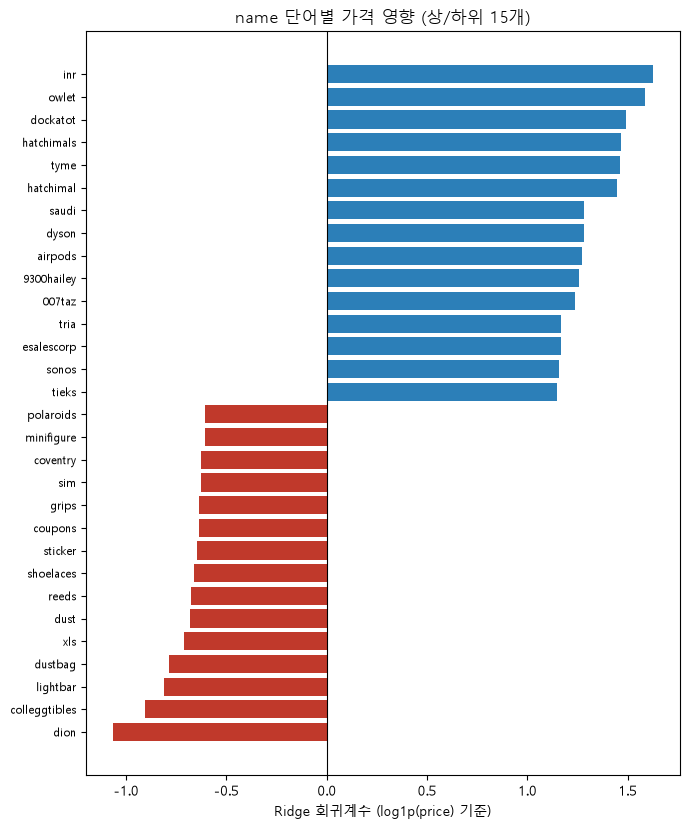

--- name 상위 15 (가격 ↑) ---
      word     coef
       inr 1.627077
     owlet 1.585044
  dockatot 1.494577
hatchimals 1.467850
      tyme 1.463087
 hatchimal 1.446586
     saudi 1.284819
     dyson 1.281520
   airpods 1.273259
9300hailey 1.258904
    007taz 1.236271
      tria 1.170016
esalescorp 1.168240
     sonos 1.158615
     tieks 1.149101
--- name 하위 15 (가격 ↓) ---
         word      coef
         dion -1.066920
colleggtibles -0.904658
     lightbar -0.812282
      dustbag -0.787849
          xls -0.713082
         dust -0.680554
        reeds -0.676476
    shoelaces -0.659829
      sticker -0.647081
      coupons -0.636445
        grips -0.634365
          sim -0.625381
     coventry -0.625251
   minifigure -0.608395
    polaroids -0.607188


In [35]:
# name 단어별 가격 영향
plot_group_coef(feature_name_map['name'], coef_groups['name'],
                 'name 단어별 가격 영향 (상/하위 15개)',
                 os.path.join(fig_dir, 'coef_name.png'), top_n=15)

name_coef_df = pd.DataFrame({'word': feature_name_map['name'], 'coef': coef_groups['name']})
print('--- name 상위 15 (가격 ↑) ---')
print(name_coef_df.sort_values('coef', ascending=False).head(15).to_string(index=False))
print('--- name 하위 15 (가격 ↓) ---')
print(name_coef_df.sort_values('coef').head(15).to_string(index=False))

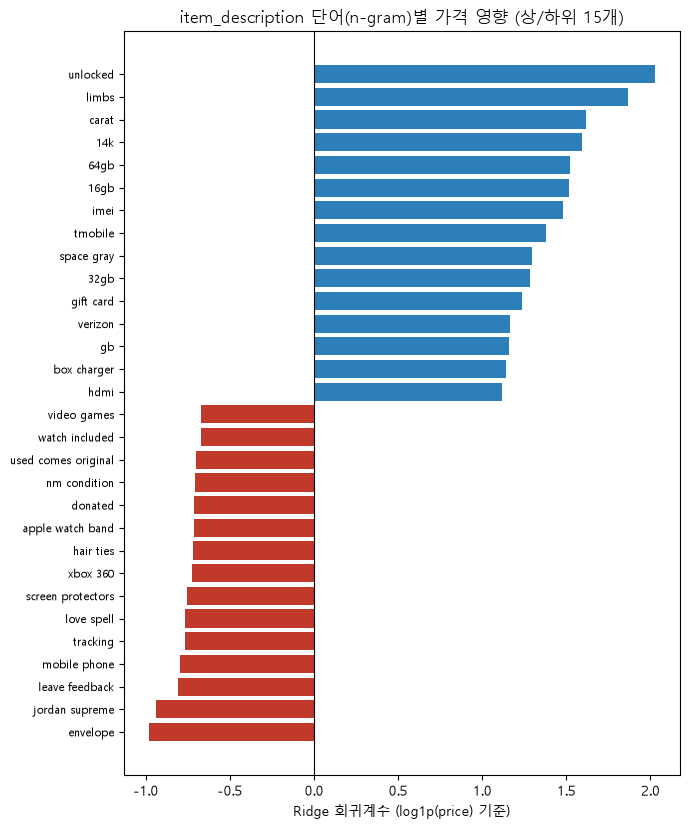

--- item_description 상위 15 (가격 ↑) ---
      ngram     coef
   unlocked 2.025936
      limbs 1.869013
      carat 1.618506
        14k 1.593668
       64gb 1.523703
       16gb 1.516439
       imei 1.480392
    tmobile 1.378247
 space gray 1.298992
       32gb 1.285666
  gift card 1.235148
    verizon 1.168168
         gb 1.160003
box charger 1.139847
       hdmi 1.119394
--- item_description 하위 15 (가격 ↓) ---
              ngram      coef
           envelope -0.980789
     jordan supreme -0.936823
     leave feedback -0.809704
       mobile phone -0.798492
           tracking -0.769729
         love spell -0.764637
  screen protectors -0.754794
           xbox 360 -0.724216
          hair ties -0.720503
   apple watch band -0.713503
            donated -0.712357
       nm condition -0.705473
used comes original -0.699983
     watch included -0.673467
        video games -0.671477


In [36]:
# item_description n-gram별 가격 영향
plot_group_coef(feature_name_map['item_description'], coef_groups['item_description'],
                 'item_description 단어(n-gram)별 가격 영향 (상/하위 15개)',
                 os.path.join(fig_dir, 'coef_description.png'), top_n=15)

descp_coef_df = pd.DataFrame({'ngram': feature_name_map['item_description'], 'coef': coef_groups['item_description']})
print('--- item_description 상위 15 (가격 ↑) ---')
print(descp_coef_df.sort_values('coef', ascending=False).head(15).to_string(index=False))
print('--- item_description 하위 15 (가격 ↓) ---')
print(descp_coef_df.sort_values('coef').head(15).to_string(index=False))

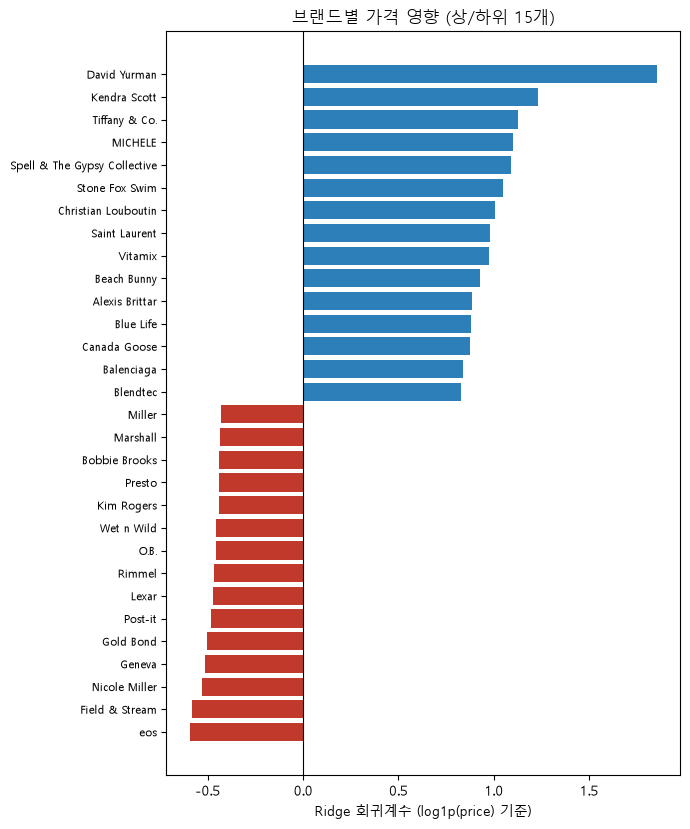

--- 브랜드 상위 15 (가격 ↑) ---
                       brand     coef
                David Yurman 1.855396
                Kendra Scott 1.233172
               Tiffany & Co. 1.128028
                     MICHELE 1.103367
Spell & The Gypsy Collective 1.090014
              Stone Fox Swim 1.047276
         Christian Louboutin 1.007423
               Saint Laurent 0.981705
                     Vitamix 0.972994
                 Beach Bunny 0.929196
              Alexis Brittar 0.883842
                   Blue Life 0.882296
                Canada Goose 0.873788
                  Balenciaga 0.839393
                    Blendtec 0.830494
--- 브랜드 하위 15 (가격 ↓) ---
         brand      coef
           eos -0.594334
Field & Stream -0.582974
 Nicole Miller -0.530657
        Geneva -0.516195
     Gold Bond -0.502601
       Post-it -0.481613
         Lexar -0.473440
        Rimmel -0.466918
          O.B. -0.458190
    Wet n Wild -0.455528
    Kim Rogers -0.440603
        Presto -0.439244
 Bobbie Brooks -0

In [37]:
# 브랜드별 가격 영향
plot_group_coef(feature_name_map['brand_name'], coef_groups['brand_name'],
                 '브랜드별 가격 영향 (상/하위 15개)',
                 os.path.join(fig_dir, 'coef_brand.png'), top_n=15)

brand_coef_df = pd.DataFrame({'brand': feature_name_map['brand_name'], 'coef': coef_groups['brand_name']})
print('--- 브랜드 상위 15 (가격 ↑) ---')
print(brand_coef_df.sort_values('coef', ascending=False).head(15).to_string(index=False))
print('--- 브랜드 하위 15 (가격 ↓) ---')
print(brand_coef_df.sort_values('coef').head(15).to_string(index=False))

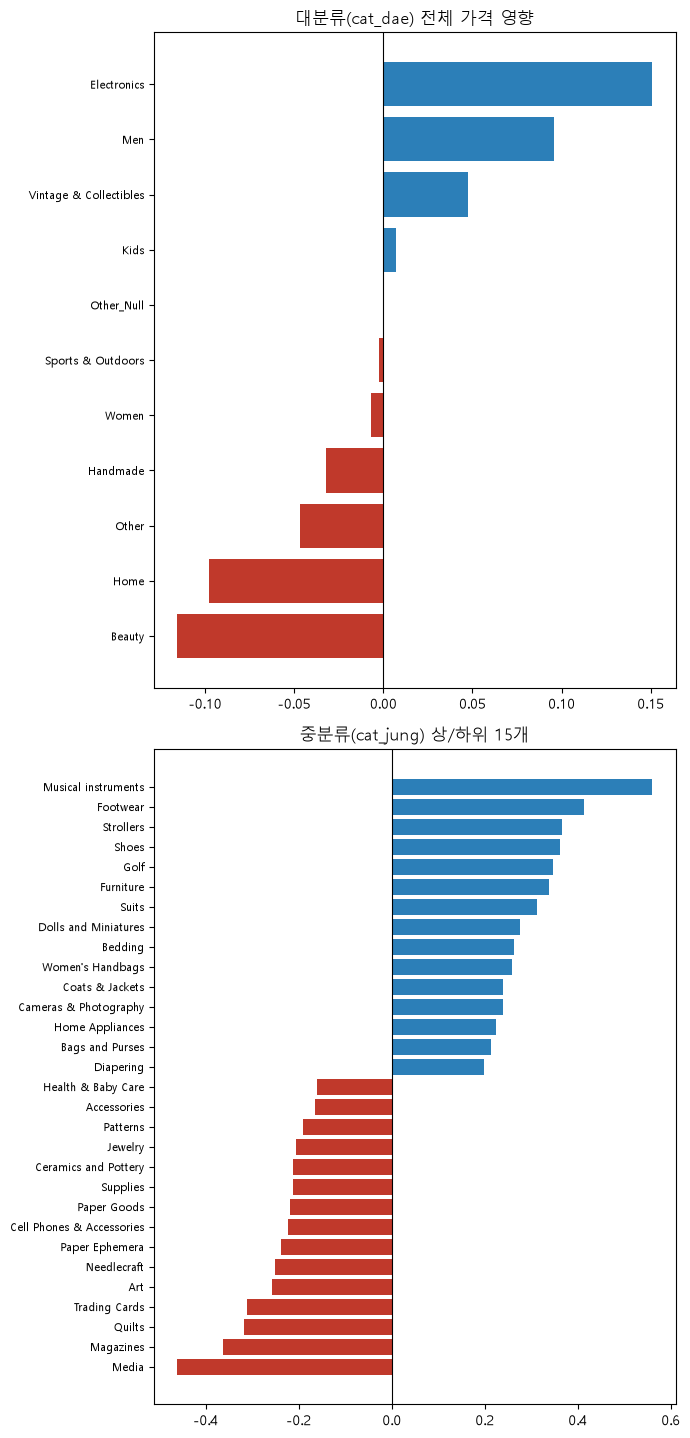

--- cat_dae 전체 ---
               cat_dae      coef
           Electronics  0.150777
                   Men  0.095793
Vintage & Collectibles  0.047699
                  Kids  0.007377
            Other_Null  0.000112
     Sports & Outdoors -0.002369
                 Women -0.006996
              Handmade -0.032204
                 Other -0.046707
                  Home -0.097966
                Beauty -0.115516
--- cat_jung 상위 15 (가격 ↑) ---
             cat_jung     coef
  Musical instruments 0.559872
             Footwear 0.412526
            Strollers 0.367129
                Shoes 0.362233
                 Golf 0.346367
            Furniture 0.339172
                Suits 0.311896
 Dolls and Miniatures 0.275631
              Bedding 0.263641
     Women's Handbags 0.257672
      Coats & Jackets 0.240174
Cameras & Photography 0.240018
      Home Appliances 0.224325
      Bags and Purses 0.213534
            Diapering 0.198310
--- cat_jung 하위 15 (가격 ↓) ---
                 cat_jung    

In [38]:
# 카테고리(대/중분류)별 가격 영향
dae_names = feature_name_map['cat_dae']
dae_coefs = coef_groups['cat_dae']
jung_names = feature_name_map['cat_jung']
jung_coefs = coef_groups['cat_jung']

fig, axes = plt.subplots(2, 1, figsize=(7, 3 + len(dae_names) * 0.28 + 30 * 0.28))

order_dae = np.argsort(dae_coefs)
names_dae_sorted = np.array(dae_names)[order_dae]
coefs_dae_sorted = dae_coefs[order_dae]
axes[0].barh(range(len(names_dae_sorted)), coefs_dae_sorted,
             color=['#c0392b' if c < 0 else '#2c7fb8' for c in coefs_dae_sorted])
axes[0].set_yticks(range(len(names_dae_sorted)))
axes[0].set_yticklabels(names_dae_sorted, fontsize=8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('대분류(cat_dae) 전체 가격 영향')

order_jung = np.argsort(jung_coefs)
idx_jung = np.concatenate([order_jung[:15], order_jung[-15:]])
names_jung_sel = np.array(jung_names)[idx_jung]
coefs_jung_sel = jung_coefs[idx_jung]
axes[1].barh(range(len(names_jung_sel)), coefs_jung_sel,
             color=['#c0392b' if c < 0 else '#2c7fb8' for c in coefs_jung_sel])
axes[1].set_yticks(range(len(names_jung_sel)))
axes[1].set_yticklabels(names_jung_sel, fontsize=8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('중분류(cat_jung) 상/하위 15개')

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'coef_category.png'), dpi=150)
plt.show()

cat_dae_df = pd.DataFrame({'cat_dae': dae_names, 'coef': dae_coefs}).sort_values('coef', ascending=False)
print('--- cat_dae 전체 ---')
print(cat_dae_df.to_string(index=False))

cat_jung_df = pd.DataFrame({'cat_jung': jung_names, 'coef': jung_coefs})
print('--- cat_jung 상위 15 (가격 ↑) ---')
print(cat_jung_df.sort_values('coef', ascending=False).head(15).to_string(index=False))
print('--- cat_jung 하위 15 (가격 ↓) ---')
print(cat_jung_df.sort_values('coef').head(15).to_string(index=False))

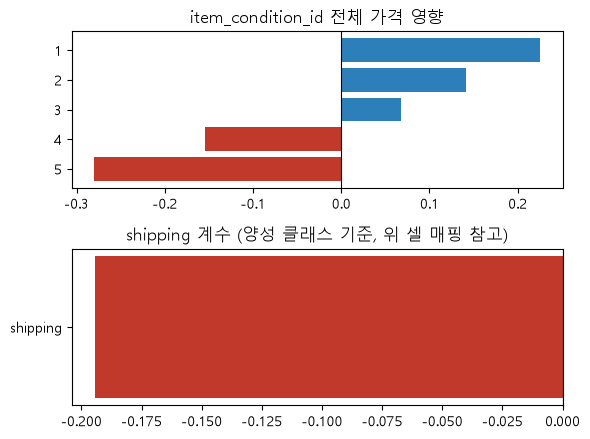

--- item_condition_id 전체 ---
 item_condition_id      coef
                 1  0.225614
                 2  0.141280
                 3  0.067922
                 4 -0.154611
                 5 -0.280205
shipping coef: -0.19429691554331496


In [39]:
# 상품상태(item_condition_id) + 배송비(shipping) 가격 영향
cond_names = feature_name_map['item_condition_id']
cond_coefs = coef_groups['item_condition_id']
ship_coef_val = float(coef_groups['shipping'][0])

fig, axes = plt.subplots(2, 1, figsize=(6, 4.5))

order_cond = np.argsort(cond_coefs)
names_cond_sorted = np.array(cond_names)[order_cond]
coefs_cond_sorted = cond_coefs[order_cond]
axes[0].barh(range(len(names_cond_sorted)), coefs_cond_sorted,
             color=['#c0392b' if c < 0 else '#2c7fb8' for c in coefs_cond_sorted])
axes[0].set_yticks(range(len(names_cond_sorted)))
axes[0].set_yticklabels(names_cond_sorted)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('item_condition_id 전체 가격 영향')

axes[1].barh([0], [ship_coef_val], color='#c0392b' if ship_coef_val < 0 else '#2c7fb8')
axes[1].set_yticks([0])
axes[1].set_yticklabels(['shipping'])
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('shipping 계수 (양성 클래스 기준, 위 셀 매핑 참고)')

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, 'coef_condition_shipping.png'), dpi=150)
plt.show()

cond_df = pd.DataFrame({'item_condition_id': cond_names, 'coef': cond_coefs}).sort_values('coef', ascending=False)
print('--- item_condition_id 전체 ---')
print(cond_df.to_string(index=False))
print('shipping coef:', ship_coef_val)